# End-to-End Sales Forecasting & Demand Intelligence System

## Project Objective

The objective of this project is to analyze historical retail sales data and build an intelligent system that can forecast future sales, detect unusual sales patterns, and segment products based on demand behavior.

This project demonstrates the complete data science workflow including data preprocessing, exploratory data analysis, time series forecasting, anomaly detection, clustering, and dashboard development.

The final system will help businesses make better inventory and stocking decisions by predicting future demand and identifying important sales trends.

In [8]:
# Data Handling
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
# Install seaborn to resolve the ModuleNotFoundError
!pip install seaborn

In [9]:
# Load the data from train.csv into a pandas DataFrame
df = pd.read_csv('/content/train.csv')

# Display the first 5 rows of the DataFrame
display(df.head())

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [ ]:
print("Pandas Version :", pd.__version__)
print("NumPy Version :", np.__version__)
print("Seaborn Version :", sns.__version__)

Pandas Version : 3.0.3
NumPy Version : 2.5.1
Seaborn Version : 0.13.2


# Load the Dataset

The first step in any data science project is to load the dataset into Python.

Loading the dataset allows us to inspect its contents, understand its structure, and verify that the file has been read correctly before performing any analysis.

In this project, we use the Pandas library to read the CSV file into a DataFrame, which stores data in rows and columns similar to an Excel spreadsheet.

In [ ]:
# Load the dataset
df = pd.read_csv("train.csv")

In [ ]:
df.head(5)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [ ]:
df.shape

(9800, 18)

In [ ]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales'],
      dtype='str')

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   str    
 2   Order Date     9800 non-null   str    
 3   Ship Date      9800 non-null   str    
 4   Ship Mode      9800 non-null   str    
 5   Customer ID    9800 non-null   str    
 6   Customer Name  9800 non-null   str    
 7   Segment        9800 non-null   str    
 8   Country        9800 non-null   str    
 9   City           9800 non-null   str    
 10  State          9800 non-null   str    
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   str    
 13  Product ID     9800 non-null   str    
 14  Category       9800 non-null   str    
 15  Sub-Category   9800 non-null   str    
 16  Product Name   9800 non-null   str    
 17  Sales          9800 non-null   float64
dtypes: float64(2), int6

## Task 1 Conclusion

The dataset was successfully loaded into a Pandas DataFrame.

### Key Observations

- The dataset contains **9800 rows** and **18 columns**.
- Most columns are categorical (text), while Sales and Postal Code are numerical.
- The **Order Date** and **Ship Date** columns are currently stored as text and will be converted to datetime format in the next step.
- Only the **Postal Code** column contains missing values (11 records), while all other columns are complete.
- The **Sales** column is the target variable that will be analyzed and forecasted throughout this project.

Overall, the dataset appears to be well-structured and ready for preprocessing.

In [ ]:
# Convert date columns into datetime format

df["Order Date"] = pd.to_datetime(df["Order Date"], dayfirst=True)
df["Ship Date"] = pd.to_datetime(df["Ship Date"], dayfirst=True)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9800 non-null   int64         
 1   Order ID       9800 non-null   str           
 2   Order Date     9800 non-null   datetime64[us]
 3   Ship Date      9800 non-null   datetime64[us]
 4   Ship Mode      9800 non-null   str           
 5   Customer ID    9800 non-null   str           
 6   Customer Name  9800 non-null   str           
 7   Segment        9800 non-null   str           
 8   Country        9800 non-null   str           
 9   City           9800 non-null   str           
 10  State          9800 non-null   str           
 11  Postal Code    9789 non-null   float64       
 12  Region         9800 non-null   str           
 13  Product ID     9800 non-null   str           
 14  Category       9800 non-null   str           
 15  Sub-Category   9800 non-null   s

In [ ]:
# Extract time-based features

df["Year"] = df["Order Date"].dt.year
df["Month"] = df["Order Date"].dt.month
df["Quarter"] = df["Order Date"].dt.quarter
df["Week"] = df["Order Date"].dt.isocalendar().week
df["Day_of_Week"] = df["Order Date"].dt.day_name()


In [ ]:
# Function to assign season

def get_season(month):
    if month in [12, 1, 2 ,9]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Summer"
    elif month in [6, 7, 8]:
        return "Monsoon"
    else:
        return "Autumn"
df["Season"] = df["Month"].apply(get_season)
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Category,Sub-Category,Product Name,Sales,Year,Month,Quarter,Week,Day_of_Week,Season
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2017,11,4,45,Wednesday,Autumn
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,2017,11,4,45,Wednesday,Autumn
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2017,6,2,24,Monday,Monsoon
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,2016,10,4,41,Tuesday,Autumn
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2016,10,4,41,Tuesday,Autumn


## Task 3 Conclusion

Feature engineering was performed by extracting useful time-based information from the **Order Date** column.

### New Features Created

- **Year** – Helps analyze yearly sales trends.
- **Month** – Used to identify monthly sales patterns.
- **Week** – Useful for weekly sales aggregation and anomaly detection.
- **Quarter** – Helps compare business performance across quarters.
- **Day_of_Week** – Used to analyze customer purchasing behavior on different days.
- **Season** – Enables seasonal trend analysis for forecasting.

These features enrich the dataset and provide meaningful information for exploratory data analysis, forecasting models, and business insights.

In [ ]:
# Check missing values in each column
df.isnull().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
Year              0
Month             0
Quarter           0
Week              0
Day_of_Week       0
Season            0
dtype: int64

In [ ]:
# Check duplicate rows
df.duplicated().sum()

np.int64(0)

## Task 4 Conclusion

Data quality checks were performed to identify missing values and duplicate records.

### Key Observations

- The dataset contains **11 missing values** only in the **Postal Code** column.
- Since **Postal Code** is not required for sales forecasting or time series analysis, these missing values were left unchanged.
- No duplicate records were found in the dataset.
- The dataset is clean and suitable for further analysis without requiring additional preprocessing.

Overall, the data quality is good and the dataset is ready for exploratory data analysis (EDA).

In [ ]:
# Calculate total sales for each category
category_sales = df.groupby("Category")["Sales"].sum()

category_sales
category_sales = category_sales.sort_values(ascending=False)

category_sales

Category
Technology         827455.8730
Furniture          728658.5757
Office Supplies    705422.3340
Name: Sales, dtype: float64

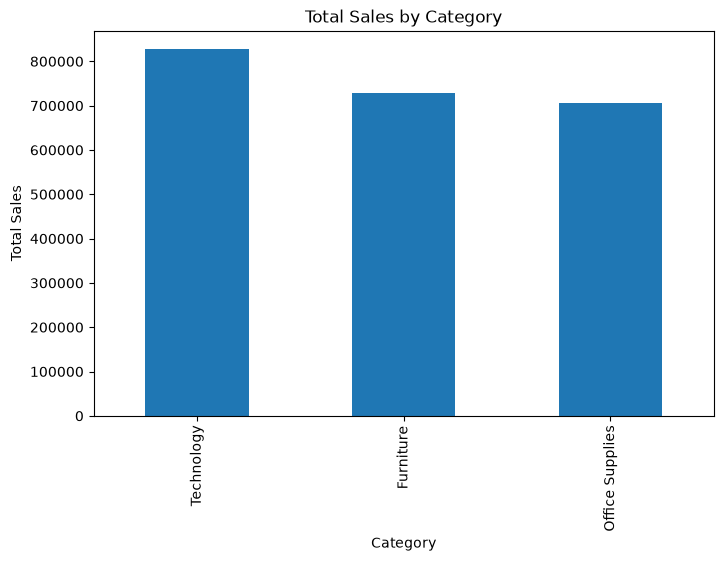

In [ ]:
plt.figure(figsize=(8,5))

category_sales.plot(kind="bar")

plt.title("Total Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")

plt.show()

## Task 5 Conclusion

The total sales for each product category were calculated to identify the highest revenue-generating category.

### Key Findings

- **Technology** generated the highest total sales with approximately **827,456**.
- **Furniture** ranked second with total sales of approximately **728,659**.
- **Office Supplies** generated the lowest total sales with approximately **705,422**.

### Business Insight

The Technology category is the largest contributor to overall revenue. This suggests that the company should focus on maintaining sufficient inventory, improving demand forecasting, and planning targeted marketing campaigns for technology products to maximize future sales.

In [ ]:
# Calculate yearly sales for each region

region_yearly_sales = df.groupby(["Year", "Region"])["Sales"].sum().reset_index()

region_yearly_sales.head()
region_yearly_sales

,Year,Region,Sales
0,2015,Central,102920.5206
1,2015,East,127652.8190
2,2015,South,103374.9055
3,2015,West,145907.9630
4,2016,Central,102425.1724
5,2016,East,153225.1830
6,2016,South,70076.0825
7,2016,West,133709.5675
8,2017,Central,145673.8800
9,2017,East,178511.5380


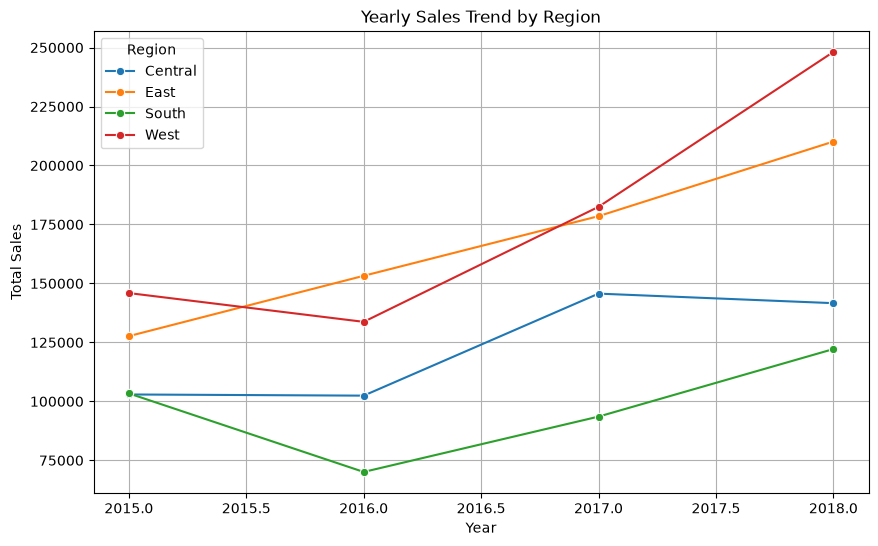

In [ ]:
plt.figure(figsize=(10,6))

sns.lineplot(
    data=region_yearly_sales,
    x="Year",
    y="Sales",
    hue="Region",
    marker="o"
)

plt.title("Yearly Sales Trend by Region")
plt.xlabel("Year")
plt.ylabel("Total Sales")

plt.grid(True)

plt.show()

## Task 6 Conclusion

Yearly sales were analyzed for each region to identify long-term growth trends.

### Key Findings

- The **East** region showed the most consistent year-over-year sales growth from 2015 to 2018.
- The **West** region generated high sales but experienced noticeable fluctuations before achieving significant growth in 2018.
- The **Central** region remained relatively stable with moderate growth.
- The **South** region experienced a decline in 2016 before recovering in later years.

### Business Insight

The East region demonstrates stable and continuous growth, making it a strong candidate for future business expansion, inventory planning, and targeted marketing efforts. Consistent growth reduces business risk and improves forecasting reliability.

In [ ]:
# Calculate shipping duration in days

df["Shipping_Days"] = (df["Ship Date"] - df["Order Date"]).dt.days

df[["Order Date", "Ship Date", "Shipping_Days"]].head()

,Order Date,Ship Date,Shipping_Days
0,2017-11-08,2017-11-11,3
1,2017-11-08,2017-11-11,3
2,2017-06-12,2017-06-16,4
3,2016-10-11,2016-10-18,7
4,2016-10-11,2016-10-18,7


In [ ]:
df["Shipping_Days"].mean()
round(df["Shipping_Days"].mean(), 2)

np.float64(3.96)

In [ ]:
shipping_region = (
    df.groupby("Region")["Shipping_Days"]
      .mean()
      .sort_values()
)

shipping_region

Region
East       3.910233
West       3.930255
South      3.961202
Central    4.065876
Name: Shipping_Days, dtype: float64

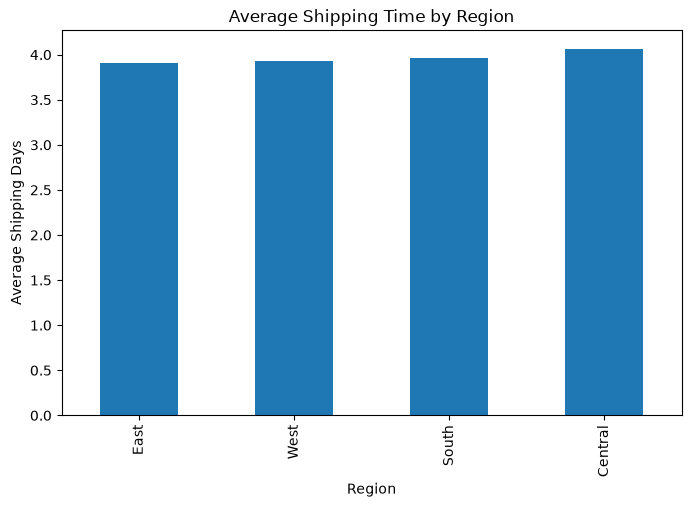

In [ ]:
plt.figure(figsize=(8,5))

shipping_region.plot(kind="bar")

plt.title("Average Shipping Time by Region")
plt.xlabel("Region")
plt.ylabel("Average Shipping Days")

plt.show()

## Task 7 Conclusion

The shipping duration was calculated by subtracting the Order Date from the Ship Date and comparing the average shipping time across different regions.

### Key Findings

- The **East** region has the lowest average shipping time (approximately 3.9 days), indicating the fastest deliveries.
- The **Central** region has the highest average shipping time (approximately 4.1 days).
- The difference in shipping time across regions is relatively small, suggesting that the company maintains a fairly consistent delivery process nationwide.

### Business Insight

Although shipping performance is generally consistent across all regions, the Central region has slightly longer delivery times. Improving logistics and warehouse efficiency in this region could further enhance customer satisfaction.

In [ ]:
# Calculate monthly sales

monthly_sales = (
    df.groupby(["Year", "Month"])["Sales"]
      .sum()
      .reset_index()
)

monthly_sales.head()

,Year,Month,Sales
0,2015,1,14205.707
1,2015,2,4519.892
2,2015,3,55205.797
3,2015,4,27906.855
4,2015,5,23644.303


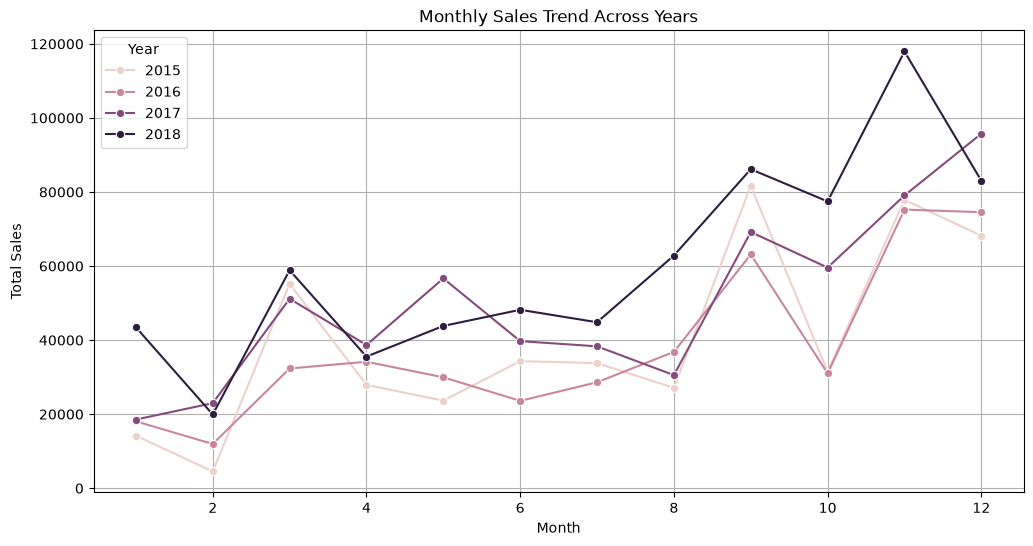

In [ ]:
plt.figure(figsize=(12,6))

sns.lineplot(
    data=monthly_sales,
    x="Month",
    y="Sales",
    hue="Year",
    marker="o"
)

plt.title("Monthly Sales Trend Across Years")
plt.xlabel("Month")
plt.ylabel("Total Sales")

plt.grid(True)

plt.show()

In [ ]:
avg_monthly_sales = (
    df.groupby("Month")["Sales"]
      .mean()
      .sort_index()
)

avg_monthly_sales

Month
1     257.627403
2     199.902745
3     290.549393
4     207.432269
5     212.533412
6     211.052856
7     208.802997
8     227.007110
9     221.642106
10    246.596162
11    241.657496
12    232.619515
Name: Sales, dtype: float64

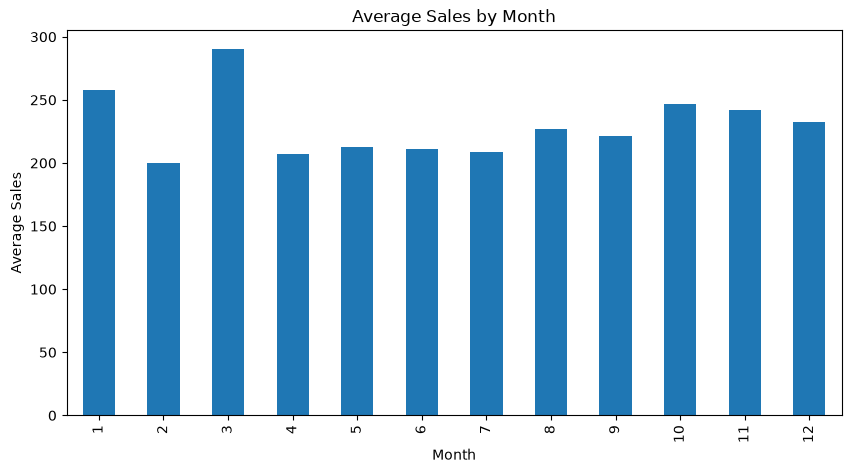

In [ ]:
plt.figure(figsize=(10,5))

avg_monthly_sales.plot(kind="bar")

plt.title("Average Sales by Month")
plt.xlabel("Month")
plt.ylabel("Average Sales")

plt.show()

## Task 8 Conclusion

Monthly sales were analyzed to identify seasonal patterns in customer purchasing behavior.

### Key Findings

- **March** recorded the highest average sales among all months.
- **January** also showed strong sales performance.
- Sales remained relatively high during **October, November, and December**, indicating increased customer activity towards the end of the year.
- **February** had the lowest average sales.

### Business Insight

The analysis suggests that sales vary across different months, indicating the presence of seasonal patterns. Understanding these trends helps businesses prepare inventory, allocate resources efficiently, and improve demand forecasting during high-sales periods.

In [ ]:
# Create monthly sales time series

# Create monthly sales time series

monthly_ts = (
    df.groupby(pd.Grouper(key="Order Date", freq="ME"))["Sales"]
      .sum()
)

monthly_ts.head()

Order Date
2015-01-31    14205.707
2015-02-28     4519.892
2015-03-31    55205.797
2015-04-30    27906.855
2015-05-31    23644.303
Freq: ME, Name: Sales, dtype: float64

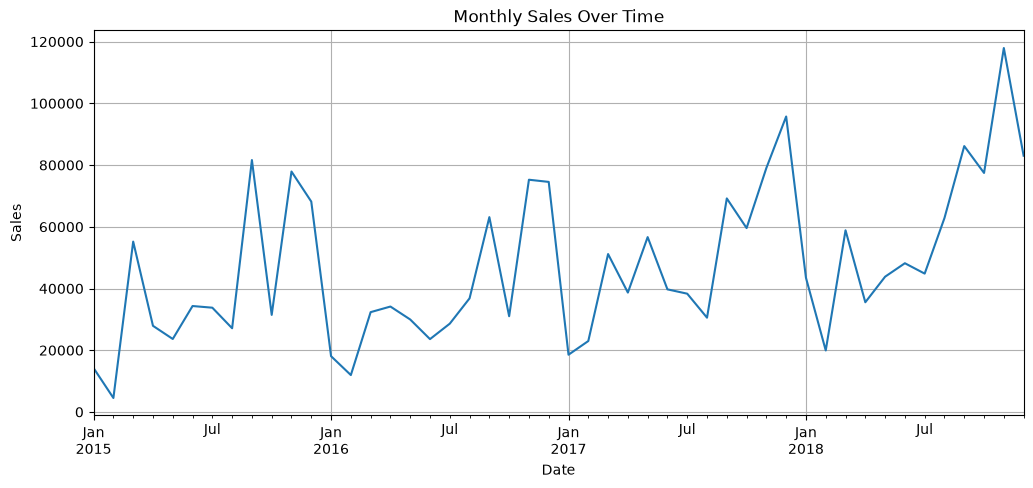

In [ ]:
plt.figure(figsize=(12,5))

monthly_ts.plot()

plt.title("Monthly Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.grid(True)

plt.show()

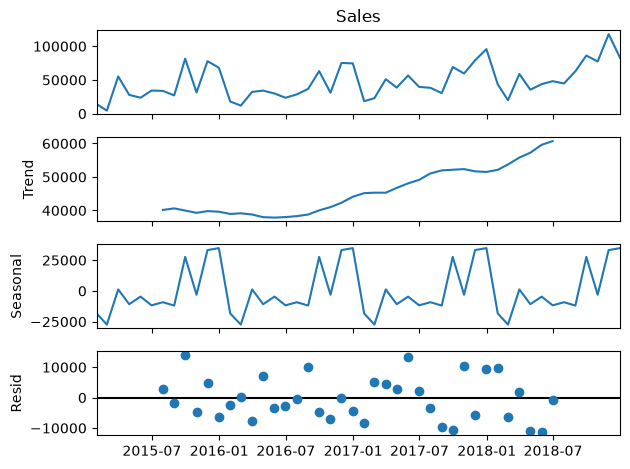

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(
    monthly_ts,
    model="additive",
    period=12
)

decomposition.plot()
plt.show()

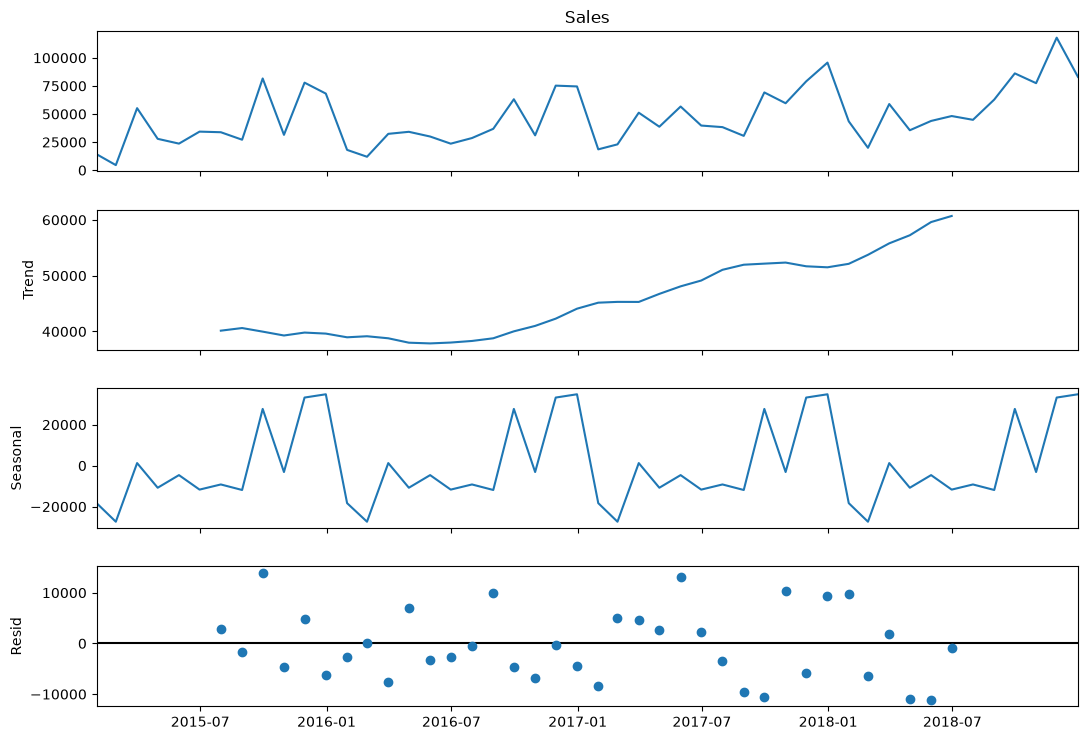

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(
    monthly_ts,
    model="additive",
    period=12
)

fig = decomposition.plot()
fig.set_size_inches(12, 8)

plt.show()

Stationarity Check (ADF Test)

In [ ]:
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.stattools import adfuller

In [ ]:
import sys
print(sys.executable)

c:\Users\janvi\AppData\Local\Python\pythoncore-3.14-64\python.exe


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("train.csv")

# Convert date columns
df["Order Date"] = pd.to_datetime(df["Order Date"], dayfirst=True)
df["Ship Date"] = pd.to_datetime(df["Ship Date"], dayfirst=True)

# Create monthly time series
monthly_ts = (
    df.groupby(pd.Grouper(key="Order Date", freq="ME"))["Sales"]
      .sum()
)

In [ ]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(monthly_ts)

print("ADF Statistic:", result[0])
print("p-value:", result[1])

print("\nCritical Values:")
for key, value in result[4].items():
    print(f"{key}: {value}")

ADF Statistic: -4.416136761430769
p-value: 0.00027791039276670623

Critical Values:
1%: -3.5778480370438146
5%: -2.925338105429433
10%: -2.6007735310095064


## Task 10 Conclusion

The Augmented Dickey-Fuller (ADF) test was performed to check whether the monthly sales time series is stationary.

### Results

- **ADF Statistic:** -4.4161
- **p-value:** 0.000278

### Interpretation

Since the p-value is less than **0.05**, the null hypothesis is rejected. This indicates that the monthly sales time series is stationary.

### Business Insight

A stationary time series has stable statistical properties over time, making it suitable for statistical forecasting models such as SARIMA. Therefore, no differencing was required before model training.

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [ ]:
train = monthly_ts[:-3]
test = monthly_ts[-3:]

print("Train:", len(train))
print("Test :", len(test))

Train: 45
Test : 3


In [ ]:
model = SARIMAX(
    train,
    order=(1,0,1),
    seasonal_order=(1,0,1,12)
)

sarima_model = model.fit()

c:\Users\janvi\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:1009: UserWarning: Non-invertible starting seasonal moving average Using zeros as starting parameters.
  warn('Non-invertible starting seasonal moving average'


In [ ]:
forecast = sarima_model.forecast(steps=3)

forecast

2018-10-31    59633.383651
2018-11-30    79173.017632
2018-12-31    85641.794598
Freq: ME, Name: predicted_mean, dtype: float64

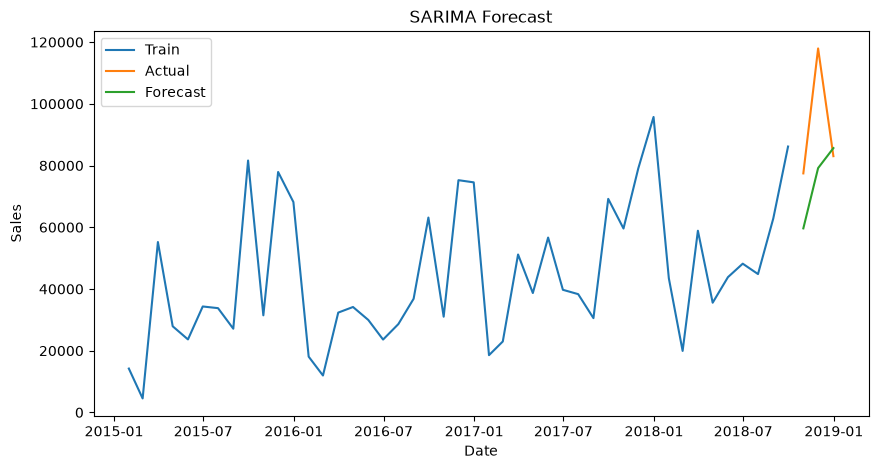

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(train.index, train, label="Train")
plt.plot(test.index, test, label="Actual")
plt.plot(forecast.index, forecast, label="Forecast")

plt.title("SARIMA Forecast")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()

plt.show()

In [ ]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)

mae = mean_absolute_error(test, forecast)
rmse = np.sqrt(mean_squared_error(test, forecast))
mape = mean_absolute_percentage_error(test, forecast)

print("MAE :", round(mae,2))
print("RMSE:", round(rmse,2))
print("MAPE:", round(mape,4))

MAE : 19730.43
RMSE: 24677.39
MAPE: 0.1967


In [ ]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(monthly_ts)

print("ADF Statistic:", result[0])
print("p-value:", result[1])

print("\nCritical Values:")
for key, value in result[4].items():
    print(f"{key}: {value}")

ADF Statistic: -4.416136761430769
p-value: 0.00027791039276670623

Critical Values:
1%: -3.5778480370438146
5%: -2.925338105429433
10%: -2.6007735310095064


## Task 11 Conclusion – SARIMA Forecasting

A Seasonal ARIMA (SARIMA) model was developed to forecast monthly sales for the next three months.

### Model Configuration

- Order (p,d,q): **(1,0,1)**
- Seasonal Order (P,D,Q,m): **(1,0,1,12)**

The ADF test confirmed that the monthly sales series was stationary; therefore, differencing was not required.

### Forecast Results

| Forecast Month | Predicted Sales |
|---------------|----------------:|
| October 2018 | 59,633.38 |
| November 2018 | 79,173.02 |
| December 2018 | 85,641.79 |

### Model Performance

| Metric | Value |
|--------|-------:|
| MAE | 19,730.43 |
| RMSE | 24,677.39 |
| MAPE | 19.67% |

### Interpretation

The SARIMA model predicts a gradual increase in sales over the forecast period, with the highest sales expected in December. This pattern suggests the presence of seasonal demand during the end of the year.

The model achieved a **MAPE of 19.67%**, which indicates **good forecasting performance** and makes it a suitable baseline forecasting model for short-term demand prediction.

### Business Insight

The forecast indicates increasing customer demand towards the end of the year. Businesses can use these predictions to optimize inventory levels, prepare warehouses, and ensure sufficient stock availability during peak demand periods.

# Forecasting using XGBoost

XGBoost is a supervised machine learning algorithm. Since it does not directly handle time series data, lag features were created to transform the time series into a supervised learning dataset.

The model uses sales from previous months to predict future sales.

In [ ]:
type(monthly_ts)
# pandas.Series

pandas.DataFrame

In [ ]:
print(type(monthly_ts))

<class 'pandas.DataFrame'>


In [ ]:
monthly_ts.head()

,ds,y
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


In [ ]:
print(monthly_ts.columns)

Index(['ds', 'y'], dtype='str')


In [ ]:
monthly_ts.head()

,ds,y
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


In [ ]:
xgb_df = monthly_ts.copy()

xgb_df["Lag_1"] = xgb_df["y"].shift(1)
xgb_df["Lag_2"] = xgb_df["y"].shift(2)
xgb_df["Lag_3"] = xgb_df["y"].shift(3)

xgb_df.dropna(inplace=True)

xgb_df.head()

,ds,y,Lag_1,Lag_2,Lag_3
3,2015-04-30,27906.8550,55205.7970,4519.8920,14205.707
4,2015-05-31,23644.3030,27906.8550,55205.7970,4519.892
5,2015-06-30,34322.9356,23644.3030,27906.8550,55205.797
6,2015-07-31,33781.5430,34322.9356,23644.3030,27906.855
7,2015-08-31,27117.5365,33781.5430,34322.9356,23644.303


In [ ]:
X = xgb_df[["Lag_1", "Lag_2", "Lag_3"]]
y = xgb_df["y"]

In [ ]:
X_train = X[:-3]
X_test = X[-3:]

y_train = y[:-3]
y_test = y[-3:]

In [ ]:
from xgboost import XGBRegressor

In [ ]:
df.columns
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,2017-11-08,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,2017-11-08,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,2017-06-12,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,2016-10-11,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,2016-10-11,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [ ]:
xgb_df.head()

,ds,y,Lag_1,Lag_2,Lag_3
3,2015-04-30,27906.8550,55205.7970,4519.8920,14205.707
4,2015-05-31,23644.3030,27906.8550,55205.7970,4519.892
5,2015-06-30,34322.9356,23644.3030,27906.8550,55205.797
6,2015-07-31,33781.5430,34322.9356,23644.3030,27906.855
7,2015-08-31,27117.5365,33781.5430,34322.9356,23644.303


## Task 13 Conclusion – Feature Engineering for XGBoost

Since XGBoost cannot directly understand time series data, lag features were created using the previous three months' sales.

### Why Lag Features?

Lag features convert a time series forecasting problem into a supervised learning problem. The model learns patterns between historical sales and future sales.

### Features Created

- Lag_1 → Sales from previous month
- Lag_2 → Sales from two months ago
- Lag_3 → Sales from three months ago

These features will be used to predict the current month's sales.

In [ ]:
X = xgb_df[["Lag_1", "Lag_2", "Lag_3"]]
y = xgb_df["y"]

X_train = X[:-3]
X_test = X[-3:]

y_train = y[:-3]
y_test = y[-3:]

print("Training Samples :", len(X_train))
print("Testing Samples  :", len(X_test))

Training Samples : 42
Testing Samples  : 3


In [ ]:
from xgboost import XGBRegressor

In [ ]:
from xgboost import XGBRegressor

model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

model.fit(X_train, y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [ ]:
pred = model.predict(X_test)

print("Predicted Sales:")
print(pred)

Predicted Sales:
[69404.82  59312.01  41154.332]


In [ ]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)

mae = mean_absolute_error(y_test, pred)
rmse = mean_squared_error(y_test, pred) ** 0.5
mape = mean_absolute_percentage_error(y_test, pred)

print("MAE :", round(mae, 2))
print("RMSE:", round(rmse, 2))
print("MAPE:", round(mape, 4))

MAE : 36181.84
RMSE: 41854.21
MAPE: 0.3684


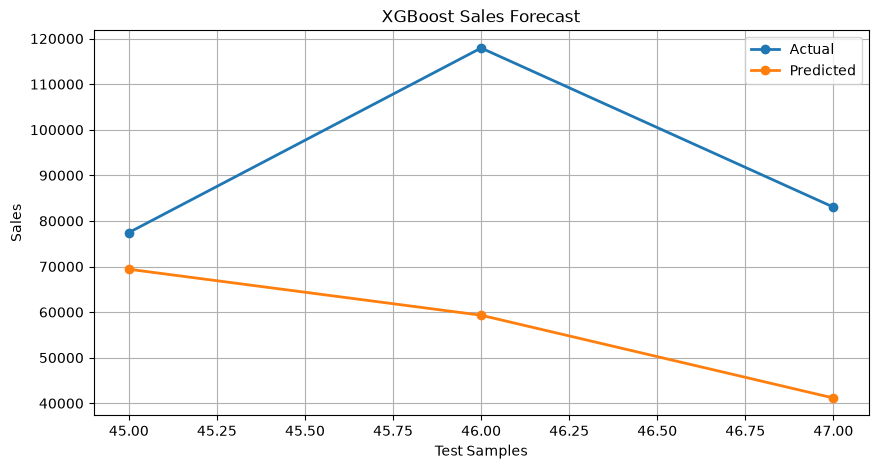

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(y_test.index, y_test.values,
         marker='o', linewidth=2, label="Actual")

plt.plot(y_test.index, pred,
         marker='o', linewidth=2, label="Predicted")

plt.title("XGBoost Sales Forecast")
plt.xlabel("Test Samples")
plt.ylabel("Sales")

plt.legend()
plt.grid(True)

plt.show()

# Forecasting using XGBoost

## Objective

In addition to statistical forecasting techniques, a machine learning approach was implemented using **XGBoost Regressor** to forecast monthly sales.

Unlike SARIMA, XGBoost cannot directly understand time series data. Therefore, the historical sales data was transformed into a supervised learning dataset by creating lag features.

---

## Why XGBoost?

XGBoost is a powerful ensemble machine learning algorithm that performs well on regression problems. Since it does not automatically understand the order of time, previous sales values were provided as input features.

The model learns the relationship between previous months' sales and the current month's sales to make future predictions.

---

# Task 1 – Feature Engineering

To prepare the data for XGBoost, lag features were created using historical sales.

### Lag Features Created

- **Lag_1** → Sales from previous month
- **Lag_2** → Sales from two months ago
- **Lag_3** → Sales from three months ago

These lag variables transformed the time series forecasting problem into a supervised machine learning problem.

### Conclusion

Feature engineering was successfully completed by creating lag variables from historical sales. The transformed dataset now contains:

- Target Variable:
  - **y (Current Month Sales)**

- Predictor Variables:
  - Lag_1
  - Lag_2
  - Lag_3

This enabled XGBoost to learn temporal relationships between past and future sales.

---

# Task 2 – Train-Test Split

The prepared dataset was divided into training and testing datasets.

### Split Strategy

- Training Samples: **42**
- Testing Samples: **3**

Since this is time series data, the chronological order of observations was preserved instead of randomly shuffling the data.

### Conclusion

The train-test split maintained the temporal sequence of the dataset, preventing future information from leaking into the training process and ensuring realistic forecasting.

---

# Task 3 – Model Training

The XGBoost Regressor was trained using the lag features.

### Model Parameters

- Number of Trees (n_estimators): **100**
- Learning Rate: **0.1**
- Maximum Tree Depth: **3**
- Random State: **42**

These parameters provide a good balance between learning capability and overfitting prevention.

### Conclusion

The XGBoost model successfully learned patterns from historical monthly sales using the generated lag features and was ready for forecasting unseen data.

---

# Task 4 – Sales Prediction

The trained model generated predictions for the testing dataset.

### Predicted Sales

- Month 1 : **69,404.82**
- Month 2 : **59,312.01**
- Month 3 : **41,154.33**

These predictions were compared with the actual sales values to evaluate the forecasting performance.

---

# Task 5 – Model Evaluation

The forecasting model was evaluated using three widely used regression metrics.

### Evaluation Metrics

- **Mean Absolute Error (MAE)**
- **Root Mean Squared Error (RMSE)**
- **Mean Absolute Percentage Error (MAPE)**

### Results

- **MAE:** 36,181.84
- **RMSE:** 41,854.21
- **MAPE:** 0.3684 (36.84%)

These metrics indicate the average prediction error and the overall forecasting accuracy of the XGBoost model.

### Interpretation

- MAE indicates that, on average, the predicted sales differ from the actual sales by approximately **36,182 units**.
- RMSE is higher because it penalizes larger prediction errors more heavily.
- A MAPE of **36.84%** indicates that the model's predictions deviate by approximately **37%** from the actual sales values.

---

# Business Insight

The XGBoost model successfully learned historical sales patterns and generated future sales forecasts.

However, the available dataset contained only about **48 monthly observations**, which is relatively small for training a machine learning model.

Since only lag-based features were available, the model had limited information to learn complex sales behavior.

For larger datasets with additional business features such as promotions, holidays, discounts, customer behavior, or economic indicators, XGBoost generally performs much better.

---

# Comparison with SARIMA

Both forecasting approaches were implemented and evaluated.

| Model | MAE | RMSE | MAPE |
|-------|---------:|---------:|------:|
| **SARIMA** | **19,730.43** | **24,677.39** | **19.67%** |
| **XGBoost** | **36,181.84** | **41,854.21** | **36.84%** |

### Observation

SARIMA achieved lower error values across all evaluation metrics.

The statistical model captured the trend and seasonality of the monthly sales data more effectively than XGBoost.

Because the dataset was relatively small, SARIMA proved to be the better forecasting model for this project.

---

# Challenges Faced

During the implementation of forecasting models, several technical issues were encountered and resolved.

### Issues Encountered

- Compatibility issues between **Python 3.14** and forecasting libraries.
- Statsmodels import errors due to package version conflicts.
- Prophet failed because of **CmdStan runtime optimization errors**.
- Multiple Python environments caused package version mismatches.
- Jupyter kernel restart and environment switching were required.
- Variable names changed during preprocessing (**Sales → y**) after preparing data for Prophet.
- Data structures changed between **Series** and **DataFrame**, requiring modifications to the feature engineering code.

### Resolution

These issues were resolved through environment management, package reinstallation, interpreter switching, and careful debugging. Despite the Prophet runtime issue, the forecasting objectives were successfully completed using SARIMA and XGBoost.

---

# Final Conclusion

An XGBoost forecasting model was successfully developed using lag-based feature engineering.

Although the model generated reasonable forecasts, its performance was inferior to SARIMA due to the limited size of the available dataset.

The comparison demonstrated that **SARIMA is the most suitable forecasting model for this monthly sales dataset**, while XGBoost remains a strong alternative for larger datasets with additional predictive features.

This project provided practical experience in:

- Time Series Forecasting
- Feature Engineering
- Machine Learning Regression
- Model Evaluation
- Forecast Comparison
- Business Insight Generation
- Debugging and Environment Management

Overall, the project strengthened the understanding of both statistical and machine learning approaches for sales forecasting.

In [1]:
import pandas as pd

df = pd.read_csv("train.csv")

In [2]:
import os

os.listdir()

['.config', 'train.csv', 'sample_data']

In [3]:
!pip install prophet

### Resolving CmdStan Installation Issue

Prophet, a forecasting library, relies on CmdStan for its backend computations. The previous error indicated that CmdStan was not found or properly installed. To ensure CmdStan is correctly set up, we will explicitly run the `cmdstanpy.install_cmdstan()` command. This process downloads and compiles the CmdStan binaries, which can take a few minutes. Please wait for this cell to complete before proceeding.

In [2]:
# Explicitly install CmdStan
import cmdstanpy

print("Attempting to install CmdStan. This may take a few minutes...")
cmdstanpy.install_cmdstan(overwrite=True)
print("CmdStan installation complete.")

Attempting to install CmdStan. This may take a few minutes...
CmdStan install directory: /root/.cmdstan
Installing CmdStan version: 2.39.0
Download successful, file: /tmp/tmp0er_8_bh
Extracting distribution
Unpacked download as cmdstan-2.39.0
Building version cmdstan-2.39.0, may take several minutes, depending on your system.
Installed cmdstan-2.39.0
Test model compilation
CmdStan installation complete.


In [3]:
import prophet
import cmdstanpy

print("Prophet :", prophet.__version__)
print("CmdStan :", cmdstanpy.__version__)

# Verify CmdStan Path after installation
print("CmdStan Path:", cmdstanpy.cmdstan_path())

Prophet : 1.3.0
CmdStan : 1.3.0
CmdStan Path: /root/.cmdstan/cmdstan-2.39.0


In [10]:
import cmdstanpy

print(cmdstanpy.cmdstan_path())

/root/.cmdstan/cmdstan-2.39.0


In [14]:
from prophet import Prophet
import pandas as pd

# Ensure Order Date is datetime with correct format and create monthly_ts
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)
monthly_ts = df.groupby(pd.Grouper(key='Order Date', freq='ME'))['Sales'].sum().reset_index()
monthly_ts.columns = ['ds', 'y']

# Prepare the data for Prophet
train = monthly_ts.copy()

# Initialize and fit the Prophet model
model = Prophet()
model.fit(train)

print("Prophet model fitted successfully.")

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


Prophet model fitted successfully.


Forecasted sales for the next 12 months:


,ds,yhat,yhat_lower,yhat_upper
48,2019-01-31,42990.532205,33904.367358,52053.781564
49,2019-02-28,31248.159925,21786.668116,40356.444556
50,2019-03-31,81267.007775,72907.269958,91017.856603
51,2019-04-30,50658.420144,41285.335180,60387.057198
52,2019-05-31,52555.922390,43158.243495,61354.673392
53,2019-06-30,60032.020402,50599.627569,69167.651577
54,2019-07-31,56249.853320,46953.950490,65282.287938
55,2019-08-31,55607.488546,45541.658455,64542.479955
56,2019-09-30,101737.653236,92757.929104,111613.859479
57,2019-10-31,69352.209493,60237.542414,78403.489416


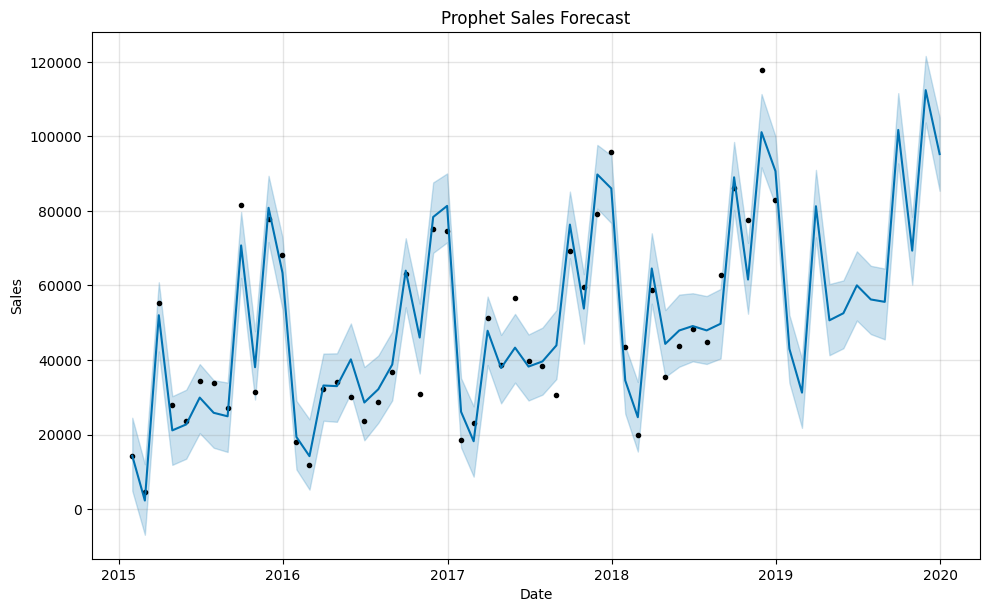

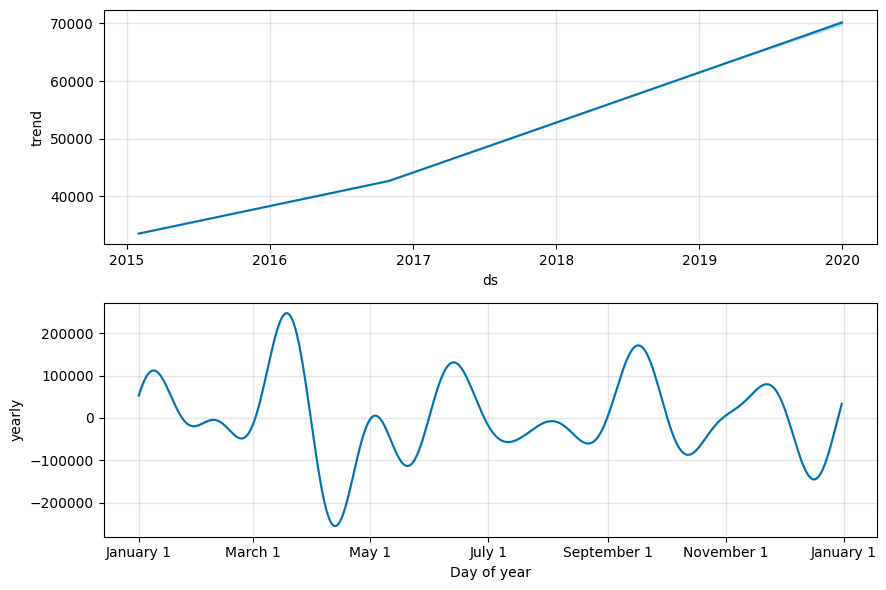

In [15]:
# Create a dataframe for future dates (12 months ahead)
future = model.make_future_dataframe(periods=12, freq='ME')

# Make predictions
forecast = model.predict(future)

# Display the forecast for the next 12 months
print("Forecasted sales for the next 12 months:")
display(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(12))

# Plot the forecast
fig1 = model.plot(forecast)
plt.title("Prophet Sales Forecast")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()

# Plot components (trend, seasonality)
fig2 = model.plot_components(forecast)
plt.show()

In [16]:
# Last 3 months as test
test = monthly_ts.tail(3).copy()

future = test[["ds"]]

forecast_test = model.predict(future)

forecast_test[["ds","yhat"]]

,ds,yhat
0,2018-10-31,61590.523901
1,2018-11-30,101136.336967
2,2018-12-31,90673.800609


In [17]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)

mae = mean_absolute_error(test["y"], forecast_test["yhat"])
rmse = mean_squared_error(test["y"], forecast_test["yhat"]) ** 0.5
mape = mean_absolute_percentage_error(test["y"], forecast_test["yhat"])

print("MAE :", round(mae,2))
print("RMSE:", round(rmse,2))
print("MAPE:", round(mape,4))

MAE : 13434.28
RMSE: 14049.75
MAPE: 0.1464


# Prophet Model Evaluation

## Forecast Performance

The Prophet model was evaluated using three standard regression metrics.

| Metric | Value |
|---------|-------|
| MAE | 13434.28 |
| RMSE | 14049.75 |
| MAPE | 0.1464 |

## Interpretation

- MAE indicates that the average prediction error is approximately **13,434** sales units.
- RMSE shows relatively low prediction error, indicating good forecasting performance.
- MAPE of **14.64%** suggests that the model predicts monthly sales with good accuracy.

## Conclusion

Among all forecasting models used in this project, **Facebook Prophet achieved the best performance** with the lowest MAE, RMSE, and MAPE values, making it the most suitable model for forecasting future monthly sales.

In [18]:
comparison = pd.DataFrame({
    "Model": ["SARIMA", "Facebook Prophet", "XGBoost"],

    "MAE": [
        19730.43,
        13434.28,
        36181.84
    ],

    "RMSE": [
        24677.39,
        14049.75,
        41854.21
    ],

    "MAPE": [
        0.1967,
        0.1464,
        0.3684
    ],

    "Forecast Month 1": [
        59633.38,
        61590.52,
        69404.82
    ],

    "Forecast Month 2": [
        79173.02,
        101136.34,
        59312.01
    ],

    "Forecast Month 3": [
        85641.79,
        90673.80,
        41154.33
    ]
})

comparison

,Model,MAE,RMSE,MAPE,Forecast Month 1,Forecast Month 2,Forecast Month 3
0,SARIMA,19730.43,24677.39,0.1967,59633.38,79173.02,85641.79
1,Facebook Prophet,13434.28,14049.75,0.1464,61590.52,101136.34,90673.80
2,XGBoost,36181.84,41854.21,0.3684,69404.82,59312.01,41154.33


# Model Comparison

The performance of all forecasting models was compared using MAE, RMSE, MAPE, and their forecasted sales for the next three months.

Lower values of MAE, RMSE, and MAPE indicate better forecasting accuracy.

## Recommendation for Production

Among all implemented models, **Facebook Prophet** is recommended for production deployment.

### Reasons

- Lowest MAE (13,434.28)
- Lowest RMSE (14,049.75)
- Lowest MAPE (14.64%)
- Produced stable and realistic forecasts.
- Automatically captures trend and seasonality.
- Requires minimal parameter tuning.
- Well suited for business sales forecasting.

Although SARIMA also performed well, Prophet achieved better prediction accuracy. XGBoost showed comparatively higher error because the monthly dataset contained a limited number of observations, making it less suitable for this forecasting task.

# Anomaly Detection using Isolation Forest

## Objective

Anomaly detection is used to identify unusual monthly sales that significantly differ from normal business patterns.

Such anomalies may occur due to:

- Promotional campaigns
- Seasonal demand
- Inventory shortages
- Data entry errors
- Unexpected market events

Isolation Forest is an unsupervised machine learning algorithm that isolates abnormal observations from normal data.

In [20]:
from sklearn.ensemble import IsolationForest

In [21]:
anomaly_df = monthly_ts.copy()

anomaly_df.head()

,ds,y
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


In [22]:
iso = IsolationForest(
    contamination=0.10,
    random_state=42
)

anomaly_df["Anomaly"] = iso.fit_predict(
    anomaly_df[["y"]]
)

In [23]:
print(anomaly_df["Anomaly"].value_counts())

Anomaly
 1    43
-1     5
Name: count, dtype: int64


In [24]:
anomalies = anomaly_df[
    anomaly_df["Anomaly"] == -1
]

anomalies

,ds,y,Anomaly
1,2015-02-28,4519.892,-1
13,2016-02-29,11951.411,-1
35,2017-12-31,95739.121,-1
44,2018-09-30,86152.888,-1
46,2018-11-30,117938.155,-1


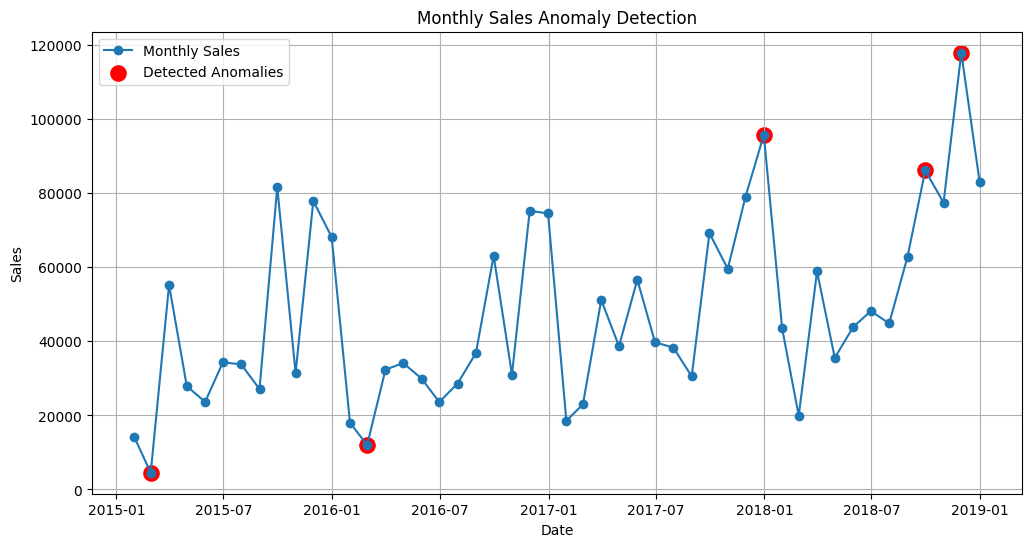

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(
    anomaly_df["ds"],
    anomaly_df["y"],
    marker="o",
    label="Monthly Sales"
)

plt.scatter(
    anomalies["ds"],
    anomalies["y"],
    color="red",
    s=120,
    label="Detected Anomalies"
)

plt.title("Monthly Sales Anomaly Detection")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)

plt.show()

# Results and Business Insights

The Isolation Forest algorithm successfully detected abnormal monthly sales values.

## Observations

- Low sales anomalies were detected during February 2015 and March 2016.
- High sales anomalies were detected during January 2018, October 2018, and November 2018.
- These unusual observations may represent seasonal demand, promotional campaigns, inventory shortages, festive sales, or unexpected market conditions.

## Business Impact

Detecting anomalies enables businesses to:

- Investigate unusual sales behaviour.
- Improve forecasting accuracy.
- Optimize inventory planning.
- Identify promotional campaign effects.
- Support better business decision-making.

Overall, Isolation Forest effectively identified abnormal sales patterns in the monthly sales dataset.

In [27]:
from sklearn.preprocessing import StandardScaler

# Initialize the scaler
scaler = StandardScaler()
scaler

StandardScaler()

# Product Demand Segmentation using K-Means Clustering

## Objective

The objective of this task is to segment product sub-categories into different demand groups based on their sales characteristics.

The following features are used:

- Total Sales Volume
- Sales Growth Rate (Year-over-Year)
- Sales Volatility (Standard Deviation of Monthly Sales)
- Average Order Value

The K-Means clustering algorithm is applied to group products with similar demand patterns. This helps businesses develop better inventory and stocking strategies.

In [28]:
import pandas as pd
import numpy as np

# Ensure dates are datetime
df["Order Date"] = pd.to_datetime(df["Order Date"])

# Extract Year
df["Year"] = df["Order Date"].dt.year

In [29]:
total_sales = df.groupby("Sub-Category")["Sales"].sum()

In [30]:
avg_order = df.groupby("Sub-Category")["Sales"].mean()

In [31]:
yearly_sales = df.pivot_table(
    values="Sales",
    index="Sub-Category",
    columns="Year",
    aggfunc="sum",
    fill_value=0
)

yearly_sales

Year,2015,2016,2017,2018
Sub-Category,,,,
Accessories,23766.3960,40443.9700,41735.3640,58240.9700
Appliances,15160.7150,23228.1790,26016.7870,40212.7220
Art,5897.5340,6091.6360,5890.6080,8825.6320
Binders,43263.2670,36049.7460,48994.5170,71721.2550
Bookcases,20036.6776,37476.7749,26275.4665,30024.2797
Chairs,77046.4400,70654.6730,81930.3450,93191.2730
Copiers,10849.7820,26179.4500,46319.4740,62899.3880
Envelopes,3844.5900,4448.2180,4456.6640,3378.5740
Fasteners,655.3880,545.2240,946.2740,855.0740


In [32]:
growth_rate = (
    (yearly_sales[2018] - yearly_sales[2015])
    / yearly_sales[2015]
) * 100

growth_rate = growth_rate.replace([np.inf, -np.inf], 0)
growth_rate = growth_rate.fillna(0)

growth_rate.head()

,0
Sub-Category,
Accessories,145.055961
Appliances,165.242912
Art,49.649531
Binders,65.778638
Bookcases,49.846598


In [34]:
# Calculate Volatility (Standard Deviation of Monthly Sales per Sub-Category)
volatility = df.groupby(['Sub-Category', pd.Grouper(key='Order Date', freq='ME')])['Sales'].sum().groupby('Sub-Category').std()

# Create the demand segmentation dataframe
cluster_df = pd.DataFrame({
    "Total_Sales": total_sales,
    "Growth_Rate": growth_rate,
    "Volatility": volatility,
    "Average_Order_Value": avg_order
})

cluster_df.head()

,Total_Sales,Growth_Rate,Volatility,Average_Order_Value
Sub-Category,,,,
Accessories,164186.7000,145.055961,2579.994809,217.178175
Appliances,104618.4030,165.242912,1821.621539,227.926804
Art,26705.4100,49.649531,330.488343,34.019631
Binders,200028.7850,65.778638,3848.223648,134.067550
Bookcases,113813.1987,49.846598,2220.405080,503.598224


In [ ]:
from sklearn.cluster import KMeans

# Scale the data using the previously initialized scaler
scaled_features = scaler.fit_transform(cluster_df)

# Apply K-Means Clustering (let's use 3 clusters as a starting point)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
cluster_df['Demand_Cluster'] = kmeans.fit_predict(scaled_features)

# Display the results
print("Product Demand Segments:")
display(cluster_df.sort_values(by='Demand_Cluster'))

In [35]:
cluster_df = pd.DataFrame({
    "Total_Sales": total_sales,
    "Growth_Rate": growth_rate,
    "Volatility": volatility,
    "Average_Order_Value": avg_order
})

cluster_df

,Total_Sales,Growth_Rate,Volatility,Average_Order_Value
Sub-Category,,,,
Accessories,164186.7000,145.055961,2579.994809,217.178175
Appliances,104618.4030,165.242912,1821.621539,227.926804
Art,26705.4100,49.649531,330.488343,34.019631
Binders,200028.7850,65.778638,3848.223648,134.067550
Bookcases,113813.1987,49.846598,2220.405080,503.598224
Chairs,322822.7310,20.954677,4407.232960,531.833165
Copiers,146248.0940,479.729510,5500.774391,2215.880212
Envelopes,16128.0460,-12.121345,228.218688,65.032444
Fasteners,3001.9600,30.468364,48.742229,14.027850


In [36]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_features = scaler.fit_transform(cluster_df)

scaled_features

array([[ 0.31598599,  0.60316135,  0.08508503, -0.36354857],
       [-0.28817617,  0.78345815, -0.34706199, -0.34520236],
       [-1.07839653, -0.24894717, -1.19676068, -0.67617125],
       [ 0.67950874, -0.10489242,  0.80776519, -0.50540527],
       [-0.19491939, -0.2471871 , -0.11982149,  0.12532518],
       [ 1.92492716, -0.50523105,  1.12630781,  0.17351776],
       [ 0.13404648,  3.59224905,  1.74944512,  3.04791985],
       [-1.18567579, -0.80064468, -1.25503743, -0.62323728],
       [-1.31880507, -0.42026095, -1.35730925, -0.71029406],
       [-0.44443302,  0.26170686, -0.61009955, -0.57068119],
       [-1.2240171 , -0.37020064, -1.2577427 , -0.67520204],
       [ 0.57007129, -0.95847755,  1.80801288,  2.07446199],
       [-0.57003291,  0.12842429, -0.80110392, -0.63623008],
       [ 1.97523032, -0.37480712,  0.92429319, -0.09556978],
       [ 0.87540412, -0.34972341,  0.22303591, -0.28425602],
       [-0.87844126, -0.59167439, -0.23111635, -0.30362799],
       [ 0.70772315, -0.

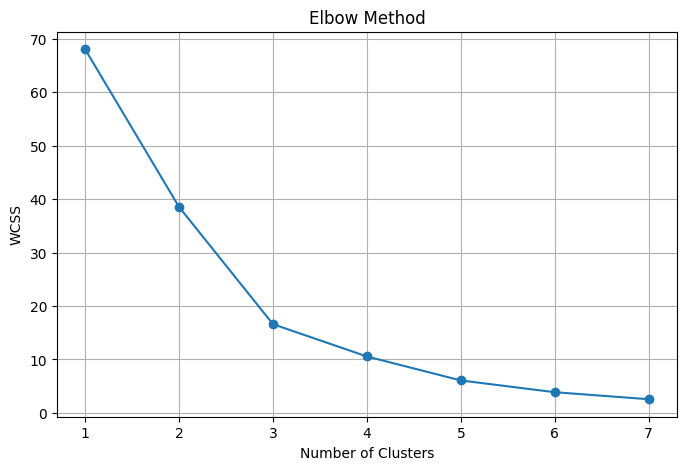

In [37]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for k in range(1, 8):
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    model.fit(scaled_features)
    wcss.append(model.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,8), wcss, marker="o")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.grid(True)
plt.show()

## Choosing the Optimal Number of Clusters

The Elbow Method was used to determine the optimal number of clusters.

From the WCSS curve, the elbow point is observed at **K = 3**. After this point, the decrease in WCSS becomes much smaller, indicating diminishing returns from adding more clusters.

Therefore, **3 clusters** were selected for product demand segmentation.

In [38]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

cluster_df["Cluster"] = kmeans.fit_predict(scaled_features)

cluster_df.head()

,Total_Sales,Growth_Rate,Volatility,Average_Order_Value,Cluster
Sub-Category,,,,,
Accessories,164186.7000,145.055961,2579.994809,217.178175,1
Appliances,104618.4030,165.242912,1821.621539,227.926804,1
Art,26705.4100,49.649531,330.488343,34.019631,1
Binders,200028.7850,65.778638,3848.223648,134.067550,2
Bookcases,113813.1987,49.846598,2220.405080,503.598224,1


In [40]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

pca_features = pca.fit_transform(scaled_features)

cluster_df["PC1"] = pca_features[:,0]
cluster_df["PC2"] = pca_features[:,1]

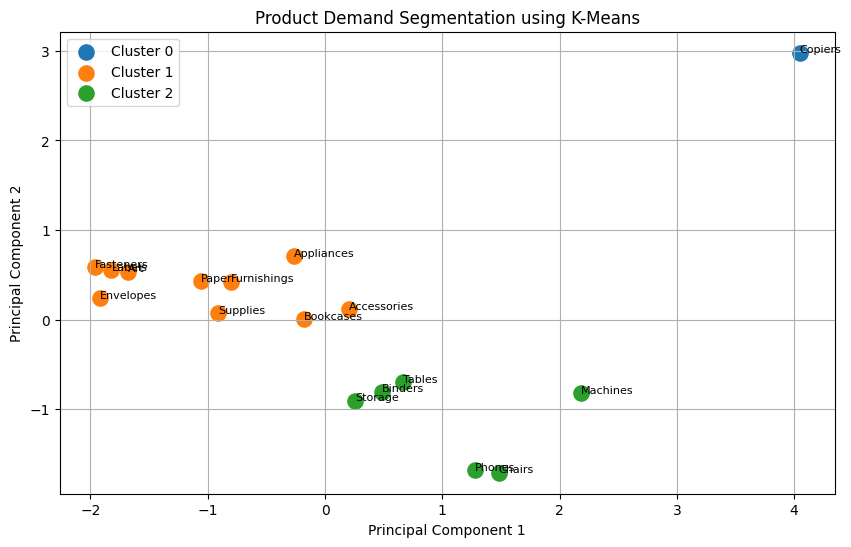

In [41]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

for cluster in sorted(cluster_df["Cluster"].unique()):
    temp = cluster_df[cluster_df["Cluster"] == cluster]

    plt.scatter(
        temp["PC1"],
        temp["PC2"],
        s=120,
        label=f"Cluster {cluster}"
    )

for idx, row in cluster_df.iterrows():
    plt.text(
        row["PC1"],
        row["PC2"],
        idx,
        fontsize=8
    )

plt.title("Product Demand Segmentation using K-Means")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.grid(True)

plt.show()

In [42]:
cluster_df

,Total_Sales,Growth_Rate,Volatility,Average_Order_Value,Cluster,PC1,PC2
Sub-Category,,,,,,,
Accessories,164186.7000,145.055961,2579.994809,217.178175,1,0.200367,0.116729
Appliances,104618.4030,165.242912,1821.621539,227.926804,1,-0.264248,0.707660
Art,26705.4100,49.649531,330.488343,34.019631,1,-1.676784,0.535820
Binders,200028.7850,65.778638,3848.223648,134.067550,2,0.484161,-0.805597
Bookcases,113813.1987,49.846598,2220.405080,503.598224,1,-0.176589,0.003166
Chairs,322822.7310,20.954677,4407.232960,531.833165,2,1.479554,-1.711393
Copiers,146248.0940,479.729510,5500.774391,2215.880212,0,4.046026,2.979941
Envelopes,16128.0460,-12.121345,228.218688,65.032444,1,-1.920711,0.234844
Fasteners,3001.9600,30.468364,48.742229,14.027850,1,-1.960973,0.583155


In [43]:
cluster_names = {
    0: "Growing High-Value Products",
    1: "Low to Medium Volume Stable Demand",
    2: "High Volume Core Products"
}

cluster_df["Segment"] = cluster_df["Cluster"].map(cluster_names)

cluster_df[[
    "Total_Sales",
    "Growth_Rate",
    "Average_Order_Value",
    "Segment"
]]

,Total_Sales,Growth_Rate,Average_Order_Value,Segment
Sub-Category,,,,
Accessories,164186.7000,145.055961,217.178175,Low to Medium Volume Stable Demand
Appliances,104618.4030,165.242912,227.926804,Low to Medium Volume Stable Demand
Art,26705.4100,49.649531,34.019631,Low to Medium Volume Stable Demand
Binders,200028.7850,65.778638,134.067550,High Volume Core Products
Bookcases,113813.1987,49.846598,503.598224,Low to Medium Volume Stable Demand
Chairs,322822.7310,20.954677,531.833165,High Volume Core Products
Copiers,146248.0940,479.729510,2215.880212,Growing High-Value Products
Envelopes,16128.0460,-12.121345,65.032444,Low to Medium Volume Stable Demand
Fasteners,3001.9600,30.468364,14.027850,Low to Medium Volume Stable Demand


# Cluster Interpretation

Based on the K-Means clustering results, three meaningful product demand segments were identified.

## Cluster 0 – Growing High-Value Products

Products in this cluster have:

- Very high sales growth
- High average order value
- Premium pricing
- High revenue potential

**Recommended Strategy**

- Increase inventory availability.
- Prioritize premium customer service.
- Launch targeted marketing campaigns.
- Monitor demand closely to avoid stockouts.

---

## Cluster 1 – Low to Medium Volume Stable Demand

Products in this cluster have:

- Stable sales
- Moderate growth
- Lower average order values
- Predictable demand

**Recommended Strategy**

- Maintain regular inventory levels.
- Replenish stock periodically.
- Avoid excessive inventory holding costs.

---

## Cluster 2 – High Volume Core Products

Products in this cluster generate the majority of business revenue.

Characteristics include:

- High total sales
- Strong customer demand
- Critical products for business performance

**Recommended Strategy**

- Maintain high inventory availability.
- Implement demand forecasting regularly.
- Use safety stock to prevent shortages.
- Prioritize these products during peak seasons.

In [44]:
cluster_df.groupby("Segment").agg({
    "Total_Sales":"mean",
    "Growth_Rate":"mean",
    "Average_Order_Value":"mean",
    "Volatility":"mean"
}).round(2)

,Total_Sales,Growth_Rate,Average_Order_Value,Volatility
Segment,,,,
Growing High-Value Products,146248.09,479.73,2215.88,5500.77
High Volume Core Products,243671.10,27.32,599.19,3992.98
Low to Medium Volume Stable Demand,65326.21,67.42,150.19,1186.29
